In [1]:
import os
import sys
# set gpu to be pci bus id
# os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
# os.environ['CUDA_VISIBLE_DEVICES'] = '2'
os.environ["JAX_PLATFORM_NAME"] = "cpu"
# set gpu memory usage and turnoff pre-allocated memory TODO: what does the following do??
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] ='false'
# os.environ['XLA_PYTHON_CLIENT_ALLOCATOR']='platform'
# os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [2]:
import jax
from jax import random
from jax import lax

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import equinox as eqx
from typing import Tuple, Optional

In [3]:
sys.path.append('/home/jmathew_waller/workspace/e2e-imaging/')
from psf_modules import RMLPSFLayer
from lensless_data_generator import LenslessDataGenerator
from optimizers import E2EOptimizer

2026-02-25 01:50:12.957137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772013012.973416 1782119 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772013012.978384 1782119 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
def conv2d(x: jnp.ndarray, psf: jnp.ndarray) -> jnp.ndarray:
    psf = psf[::-1, ::-1]
    K, L = psf.shape

    # Pad fully so conv_valid gives the 'full' result
    x_padded = jnp.pad(x, ((0,0), (K-1, K-1), (L-1, L-1)))
    x4 = x_padded[:, :, :, None]
    k4 = psf[:, :, None, None]

    y4 = lax.conv_general_dilated(
        lhs=x4,
        rhs=k4,
        window_strides=(1, 1),
        padding="VALID",
        dimension_numbers=("NHWC", "HWIO", "NHWC"),
    )
    # y4 shape is now (B, H+K-1, W+L-1, 1) — the full convolution output

    # Crop to original size, matching scipy's 'same' anchor
    crop_h = (K - 1) // 2
    crop_w = (L - 1) // 2
    H, W = x.shape[1], x.shape[2]

    return y4[:, crop_h:crop_h+H, crop_w:crop_w+W, 0]

In [5]:
def wiener_deconv(y: jnp.ndarray, psf: jnp.ndarray, K: float) -> jnp.ndarray:
    """
    y:   (B, H, W) — observed blurred image
    psf: (K, L)    — point spread function (same one used in forward model)
    K:   scalar    — noise-to-signal ratio (regularization). larger = more smoothing.
    
    returns: (B, H, W) estimate of original image
    """
    H, W = y.shape[1], y.shape[2]
    psf_h, psf_w = psf.shape

    if psf_h > H or psf_w > W:
        raise ValueError(f"PSF ({psf_h}x{psf_w}) is larger than image ({H}x{W})")
    
    # Embed PSF in the output image domain and shift so the PSF center is at (0,0)
    pad_h = (psf_h - 1) // 2
    pad_w = (psf_w - 1) // 2

    psf_padded = jnp.zeros((H, W))
    psf_padded = psf_padded.at[:psf_h, :psf_w].set(psf)
    # roll so that the center pixel of the PSF lands at (0,0)
    psf_padded = jnp.roll(psf_padded, (-pad_h, -pad_w), axis=(0, 1))

    # FFTs
    PSF = jnp.fft.rfft2(psf_padded)          # (H, W//2+1)
    Y   = jnp.fft.rfft2(y)                   # (B, H, W//2+1)

    # Wiener filter: H* / (|H|^2 + K)
    PSF_conj  = jnp.conj(PSF)
    PSF_power = jnp.abs(PSF) ** 2
    wiener    = PSF_conj / (PSF_power + K)

    X_est = wiener[None, :, :] * Y           # broadcast over batch

    return jnp.fft.irfft2(X_est, s=(H, W))  # (B, H, W)

In [6]:
class E2E(eqx.Module):
    psf_module: eqx.Module
    log_K: jnp.ndarray  # learn in log space to keep K positive

    def __init__(self, psf_module, log_K=jnp.array(-1.0), key=None):
        self.psf_module = psf_module
        self.log_K = log_K # initializes K to ~1e-4

    def __call__(self, x: jnp.ndarray) -> tuple:
        # x: (B, H, W)
        K = jnp.exp(self.log_K)  # ensure K is always positive
        psf = self.psf_module.compute_psf()  # (K, L)
        y = conv2d(x, psf)                   # (B, H, W)
        x_hat = wiener_deconv(y, psf, K)     # (B, H, W)
        return x_hat, y, psf

E0225 01:50:16.312378 1782119 cuda_dnn.cc:456] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.8.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0225 01:50:16.314846 1782119 cuda_dnn.cc:456] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.8.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.


In [7]:
# some constants
photon_count = 160
subset_fraction = 0.01 #TODO: CHANGE THIS FRACTION WHEN I FIGURE OUT THE GPU ISSUE
seed_value = 0 #TODO: FIX SEEDING
psf_size = (32, 32)
key = jax.random.PRNGKey(seed_value)
learning_rate = 1e-3
dataset_name = 'mnist'
object_size = 32
num_gaussian = 10

#other constants
tile_rows=1
tile_cols=1
batch_size=32   

# hyperparameters
log_K = jnp.array(-1.0) #initial starting K value for wiener deconv

#wandb logging stuff
use_wandb = True
project_name = 'e2e_imaging_playground'
run_name = f'mnist_photon_count_{photon_count}_num_gaussian_{num_gaussian}_photon_count_{photon_count}'
log_every = 10

In [8]:
# set up wandb config
wandb_config = {
    'general': {
        'seed_value': seed_value,
    },
    
    'dataset': {
        'subset_fraction': subset_fraction,
        'photon_count': photon_count,
        'tile_rows': tile_rows,
        'tile_cols': tile_cols,
        'batch_size': batch_size,
        'dataset_name': dataset_name,
    },
    
    'psf_layer': {
        'object_size': object_size,
        'num_gaussian': num_gaussian,
        'psf_size': psf_size,
    },
    
    'optimization': {
        'initial log_K': log_K,
        'learning_rate': learning_rate
    },
    
    'logging': {
        'use_wandb': use_wandb,
        'project_name': project_name,
        'run_name': run_name,
        'log_every': log_every,
    }
}

In [9]:
# the model
key_2, subkey_1 = jax.random.split(key)
psf_module = RMLPSFLayer(object_size=32, num_gaussians=10, psf_size=psf_size, key=subkey_1)
model = E2E(psf_module=psf_module, log_K=log_K)

In [10]:
data_generator = LenslessDataGenerator(photon_count, subset_fraction=subset_fraction, seed=seed_value)
x_train, x_test = data_generator.load_mnist_data()
train_dataset = data_generator.create_dataset(x_train, tile_rows=tile_rows, tile_cols=tile_cols, batch_size=batch_size)

I0000 00:00:1772013019.666503 1782119 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22451 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:5e:00.0, compute capability: 8.6
I0000 00:00:1772013019.667173 1782119 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 11530 MB memory:  -> device: 1, name: NVIDIA TITAN Xp, pci bus id: 0000:18:00.0, compute capability: 6.1
I0000 00:00:1772013019.667704 1782119 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 11530 MB memory:  -> device: 2, name: NVIDIA TITAN Xp, pci bus id: 0000:3b:00.0, compute capability: 6.1
I0000 00:00:1772013019.668225 1782119 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 11530 MB memory:  -> device: 3, name: NVIDIA TITAN Xp, pci bus id: 0000:86:00.0, compute capability: 6.1


In [ ]:
e2e_optimizer = E2EOptimizer(
    model=model,
    lr=learning_rate,
    use_wandb=True,
    project_name='e2e_imaging',
    run_name=run_name,
    wandb_config=wandb_config
)

wandb: Currently logged in as: julia_mathew (julia_mathew-university-of-california-berkeley) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


  0%|          | 0/500 [00:00<?, ?it/s]

THIS IS RUNNING
step 0/500  loss=180206.500000  K=0.367512


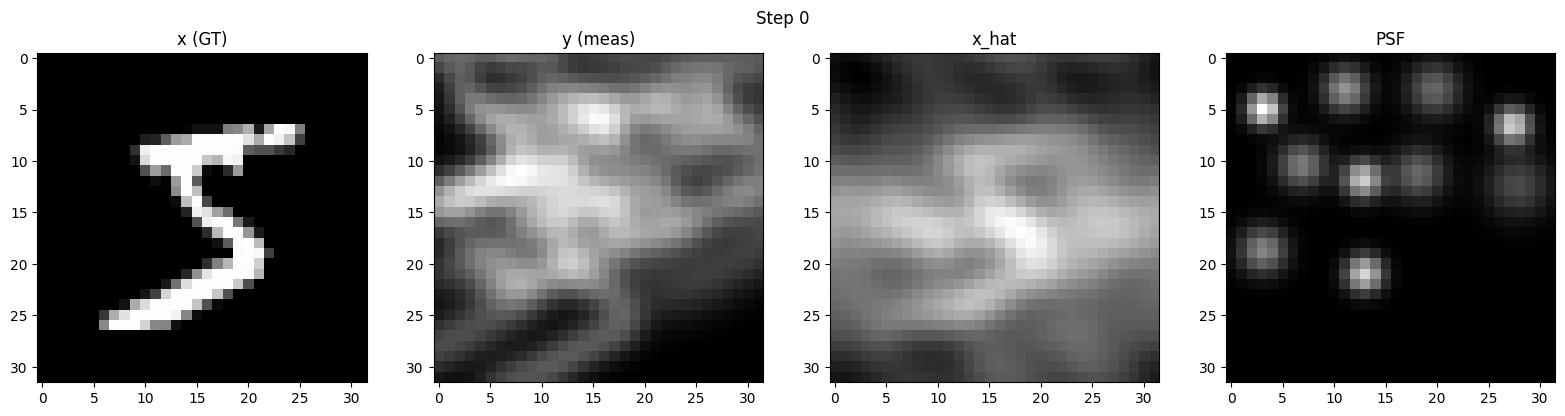

  2%|▏         | 12/500 [00:12<02:27,  3.30it/s] 

THIS IS RUNNING
step 10/500  loss=183601.062500  K=0.363836


  5%|▍         | 24/500 [00:14<01:43,  4.60it/s]

THIS IS RUNNING
step 20/500  loss=174461.078125  K=0.360161


  6%|▋         | 32/500 [00:15<00:48,  9.72it/s]

...

THIS IS RUNNING
step 80/500  loss=130516.539062  K=0.336859


 18%|█▊        | 92/500 [00:19<00:27, 14.66it/s]

THIS IS RUNNING
step 90/500  loss=133314.640625  K=0.332854


 20%|██        | 100/500 [00:19<00:28, 14.11it/s]

THIS IS RUNNING
step 100/500  loss=127830.429688  K=0.328902


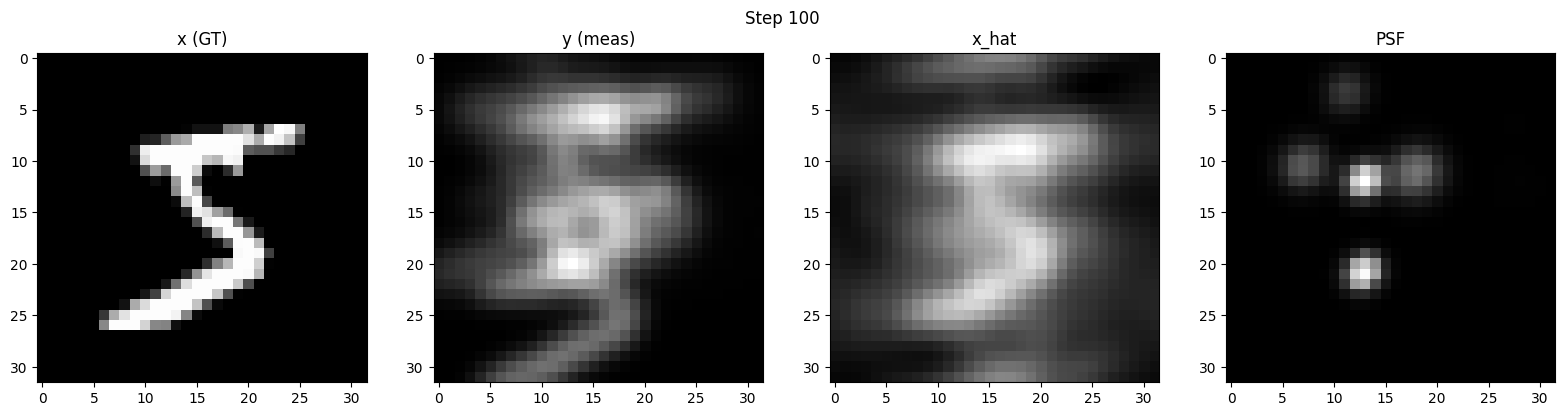

 23%|██▎       | 114/500 [00:21<00:28, 13.40it/s]

THIS IS RUNNING
step 110/500  loss=117623.906250  K=0.324959


 25%|██▍       | 124/500 [00:22<00:25, 14.85it/s]

THIS IS RUNNING
step 120/500  loss=126664.187500  K=0.321096


 26%|██▋       | 132/500 [00:22<00:23, 15.43it/s]

...

THIS IS RUNNING
step 180/500  loss=98383.195312  K=0.299357


 38%|███▊      | 192/500 [00:26<00:21, 14.02it/s]

THIS IS RUNNING
step 190/500  loss=91297.265625  K=0.296028


 40%|████      | 200/500 [00:27<00:25, 11.75it/s]

THIS IS RUNNING
step 200/500  loss=95955.976562  K=0.292769


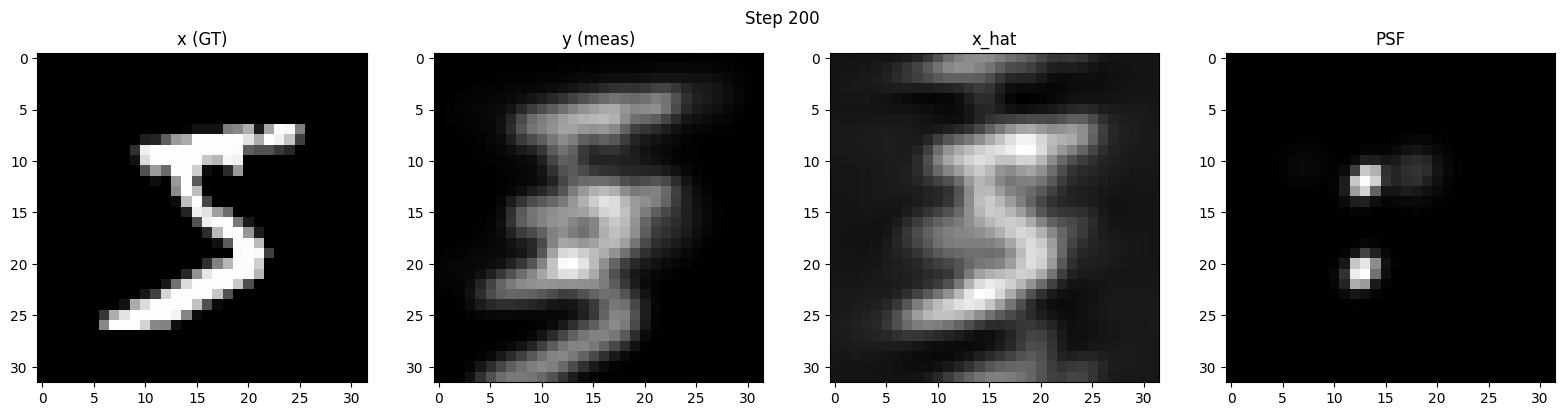

 42%|████▏     | 212/500 [00:29<00:24, 11.75it/s]

THIS IS RUNNING
step 210/500  loss=89176.960938  K=0.289614


 44%|████▍     | 222/500 [00:29<00:20, 13.58it/s]

THIS IS RUNNING
step 220/500  loss=84542.031250  K=0.286524


 46%|████▋     | 232/500 [00:30<00:19, 13.42it/s]

...

THIS IS RUNNING
step 280/500  loss=78274.968750  K=0.269519


 58%|█████▊    | 292/500 [00:34<00:15, 13.59it/s]

THIS IS RUNNING
step 290/500  loss=75928.515625  K=0.266885


 60%|██████    | 300/500 [00:35<00:14, 13.84it/s]

THIS IS RUNNING
step 300/500  loss=71628.453125  K=0.264269


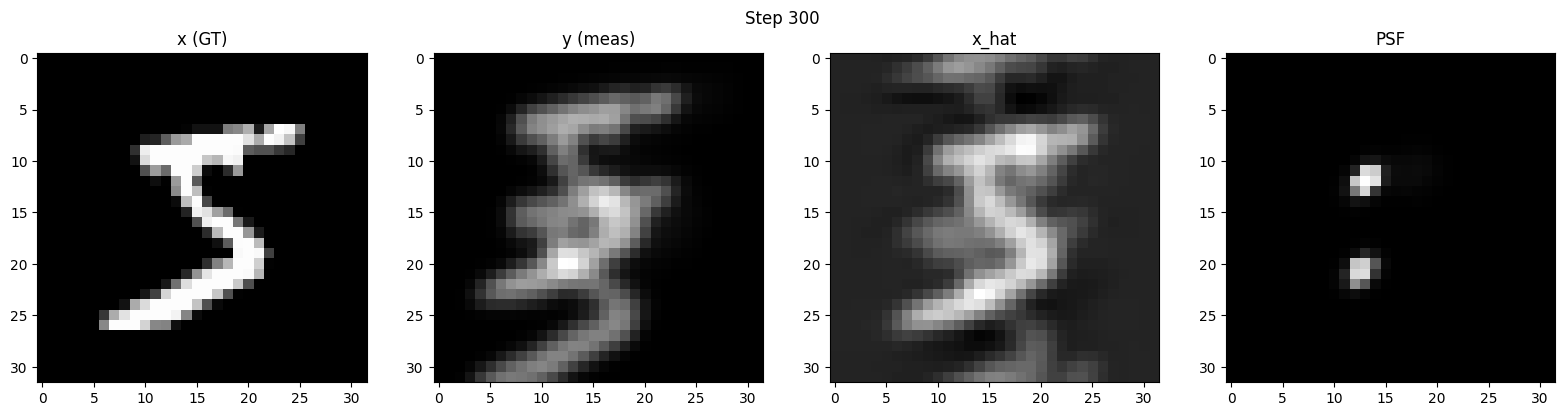

 62%|██████▏   | 312/500 [00:36<00:16, 11.43it/s]

THIS IS RUNNING
step 310/500  loss=76052.312500  K=0.261700


 64%|██████▍   | 322/500 [00:37<00:13, 13.51it/s]

THIS IS RUNNING
step 320/500  loss=72639.078125  K=0.259137


 67%|██████▋   | 334/500 [00:38<00:11, 14.44it/s]

...

THIS IS RUNNING
step 380/500  loss=50533.628906  K=0.243869


 79%|███████▉  | 394/500 [00:42<00:07, 14.83it/s]

THIS IS RUNNING
step 390/500  loss=50916.484375  K=0.241372


 80%|████████  | 400/500 [00:43<00:07, 14.21it/s]

THIS IS RUNNING
step 400/500  loss=46310.847656  K=0.238930


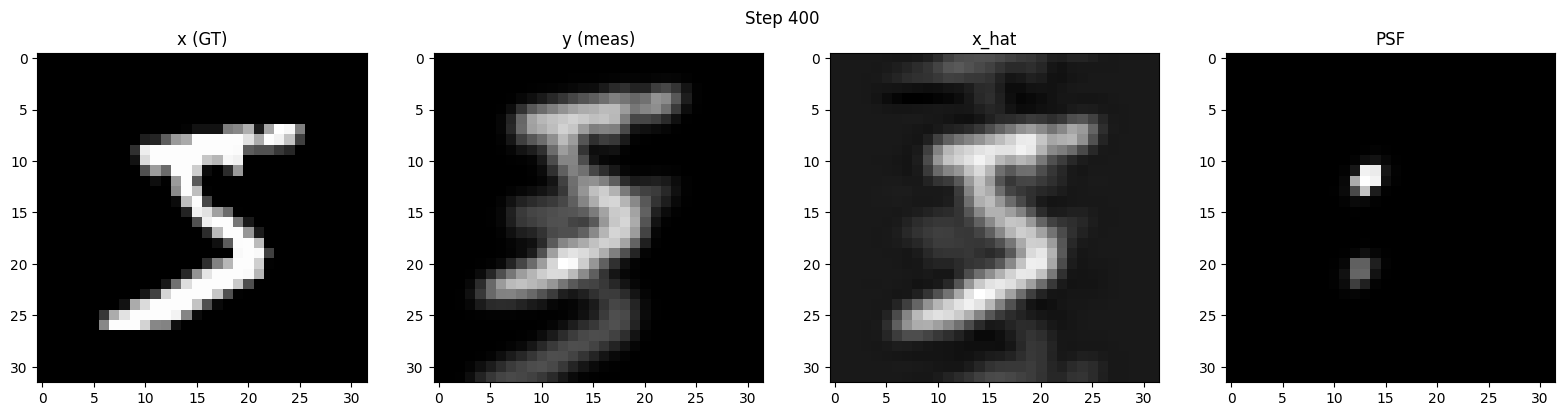

 83%|████████▎ | 414/500 [00:44<00:06, 12.56it/s]

THIS IS RUNNING
step 410/500  loss=42195.488281  K=0.236536


 84%|████████▍ | 422/500 [00:45<00:05, 13.63it/s]

THIS IS RUNNING
step 420/500  loss=43397.519531  K=0.234219


 86%|████████▋ | 432/500 [00:46<00:04, 13.65it/s]

...

THIS IS RUNNING
step 480/500  loss=31897.966797  K=0.221730


 99%|█████████▉| 494/500 [00:50<00:00, 14.75it/s]

THIS IS RUNNING
step 490/500  loss=29189.617188  K=0.219869


100%|██████████| 500/500 [00:50<00:00,  9.85it/s]


K,███▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁
loss,███▇▇▆▆▆▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
step,▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
K,0.21987
loss,29189.61719
step,490


In [12]:
optimized_imaging_system = e2e_optimizer.optimize(
    train_dataset,
    num_steps=500,
    log_every=10,
    visualize_every=100
)